---

##  Notebook Configuration and Initialization

This section configures the environment and imports the necessary modules. All the algorithms and evaluation functions called here have been previously implemented and verified in the project's source files.

###  Imports

In [2]:
# External imports
import pandas as pd
import matplotlib.pyplot as plt
# Local imports
import random

from mechanisms.serial_dictatorship import serial_dictatorship
from metrics.cost import rank_sum_cost
from data import load_dataset
from mechanisms import gale_shapley, serial_dictatorship, ttc_from_stable
from metrics import rank_sum_cost, borda_welfare_cost, top_n_assigned_cost, square_rank_sum_cost, nash_welfare_cost, max_rank_cost, unassigned_students_cost
from metrics import blocking_pairs_stability_score, justified_envy_stability_score, wasteful_capacity_stability_score

###  Configuration

In [3]:
# Real data
real_data_csv_path = "../data/projects-dsai-2026-anon.csv"
real_data_project_capacity = 5

# Cost and stability functions
top_n_assigned_cost_value_of_n = 3

---

##  Pipeline Definition and Components

This section charts the end-to-end data flow, from raw data ingestion/generation to structured output tables.

###  Matching computation

In [4]:
algorithms = {
    "gale_shapley": gale_shapley,
    "serial_dictatorship": lambda instance: serial_dictatorship(instance, [s.id for s in instance.students]),
    "top_trading_cycles": lambda instance: ttc_from_stable(gale_shapley(instance))
}

In [5]:
def compute_matching(instance):
    return {
        algorithm_name: algorithm(instance)
        for algorithm_name, algorithm in algorithms.items()
    }

###  Cost and stability computations

In [6]:
cost_stability_functions = {
    # Cost functions
    "rank_sum_cost": rank_sum_cost,
    "borda_welfare_cost": borda_welfare_cost,
    "top_n_assigned_cost": lambda matching: top_n_assigned_cost(matching, n=top_n_assigned_cost_value_of_n),
    "square_rank_sum_cost": square_rank_sum_cost,
    "nash_welfare_cost": nash_welfare_cost,
    "max_rank_cost": max_rank_cost,
    "unassigned_students_cost": unassigned_students_cost,

    # Stability functions
    "blocking_pairs_stability_score": blocking_pairs_stability_score,
    "justified_envy_stability_score": justified_envy_stability_score,
    "wasteful_capacity_stability_score": wasteful_capacity_stability_score
}

In [7]:
def compute_cost_stability(matchings):
    return pd.DataFrame.from_dict({
        alg_name: {
            cost_name: cost_fn(matching)
            for cost_name, cost_fn in cost_stability_functions.items()
        }
        for alg_name, matching in matchings.items()
    }, orient="index")

In [8]:
def plot_rank_histogram(matching, title):
    ranks = []

    for student in matching.instance.students:
        r = matching.project_rank_of(student.id)

        if r is not None:
            ranks.append(r + 1)

    plt.figure(figsize=(10,5))
    plt.hist(ranks, bins=range(1, max(ranks)+2))
    plt.xlabel("Assigned Rank")
    plt.ylabel("Students")
    plt.title(title)
    plt.show()

---

0.3113207547169811
0.2358490566037736


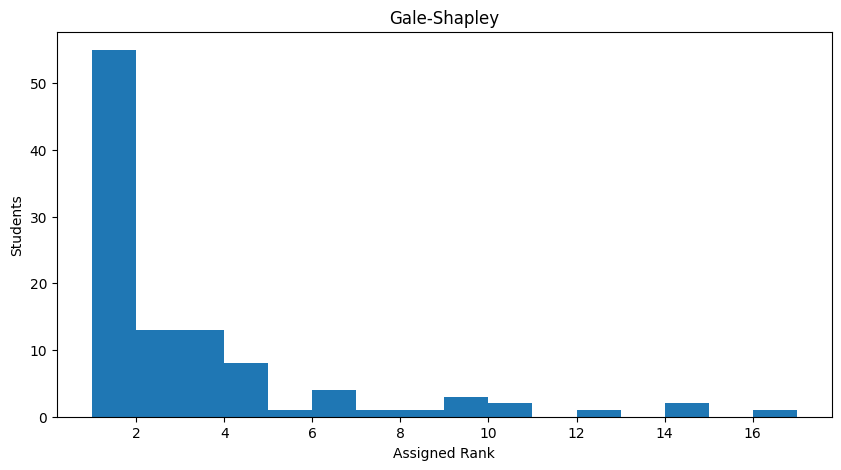

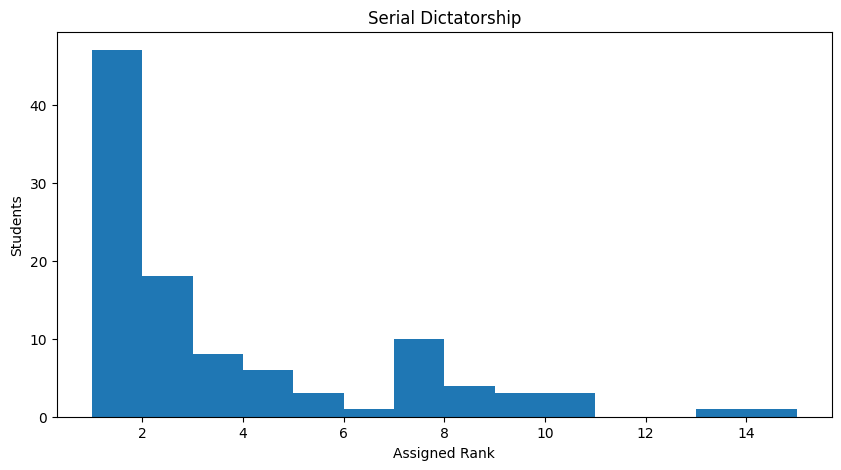

In [9]:
instance_real = load_dataset(real_data_csv_path, real_data_project_capacity,True)
matching_real = compute_matching(instance_real)
results_real = compute_cost_stability(matching_real)
print(results_real.loc["serial_dictatorship","top_n_assigned_cost"])
print(results_real.loc["gale_shapley","top_n_assigned_cost"])
plot_rank_histogram(matching_real['gale_shapley'], "Gale-Shapley")
plot_rank_histogram(matching_real["serial_dictatorship"], "Serial Dictatorship")

In [10]:
def choice_statistics(matching):

    total = len(matching.instance.students)

    first = 0
    second = 0
    third = 0
    top5 = 0

    for student in matching.instance.students:

        rank = matching.project_rank_of(student.id)

        if rank is None:
            continue

        if rank == 0:
            first += 1

        if rank == 1:
            second += 1

        if rank == 2:
            third += 1

        if rank < 5:
            top5 += 1

    return {
        "1st choice %": first / total,
        "2nd choice %": second / total,
        "3rd choice %": third / total,
        "Top 5 %": top5 / total
    }

In [11]:
print(choice_statistics(matching_real['gale_shapley']))
print(choice_statistics(matching_real["serial_dictatorship"]))

{'1st choice %': 0.5188679245283019, '2nd choice %': 0.12264150943396226, '3rd choice %': 0.12264150943396226, 'Top 5 %': 0.8490566037735849}
{'1st choice %': 0.44339622641509435, '2nd choice %': 0.16981132075471697, '3rd choice %': 0.07547169811320754, 'Top 5 %': 0.7735849056603774}


In [12]:
def best_serial_dictatorship(
    instance,
    n_runs=10000
):

    best_matching = None
    best_score = float("inf")

    students = [s.id for s in instance.students]

    for _ in range(n_runs):

        order = [student.id for student in instance_real.students]
        random.shuffle(order)

        matching = serial_dictatorship(instance, order)

        score = top_n_assigned_cost(matching,5)

        if score < best_score:
            best_score = score
            best_matching = matching

    return best_matching, best_score

In [13]:
best_sd, best_score = best_serial_dictatorship(instance_real, 10000)
print (best_score)

0.11320754716981132


In [14]:
from metrics.cost import (
    rank_sum_cost,
    square_rank_sum_cost,
    max_rank_cost,
    nash_welfare_cost,
    top_n_assigned_cost
)

def compare_matchings(gs, sd):

    return {
        "Rank Sum":
            (rank_sum_cost(gs),
             rank_sum_cost(sd)),

        "Square Rank":
            (square_rank_sum_cost(gs),
             square_rank_sum_cost(sd)),

        "Max Rank":
            (max_rank_cost(gs),
             max_rank_cost(sd)),

        "Nash":
            (nash_welfare_cost(gs),
             nash_welfare_cost(sd)),

        "Top3":
            (top_n_assigned_cost(gs,3),
             top_n_assigned_cost(sd,3))
    }

In [15]:
scores = []

for _ in range(10000):

    order = [student.id for student in instance_real.students]
    random.shuffle(order)

    matching = serial_dictatorship(instance_real, order)

    scores.append(top_n_assigned_cost(matching,5))

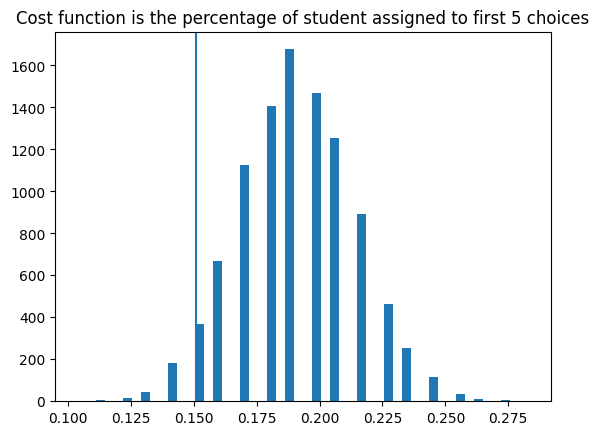

In [16]:
plt.hist(scores, bins=50)
plt.axvline(top_n_assigned_cost(matching_real['gale_shapley'],5))
plt.title("Cost function is the percentage of student assigned to first 5 choices")
plt.show()

In [17]:
scores = []

for _ in range(10000):

    order = [student.id for student in instance_real.students]
    random.shuffle(order)

    matching = serial_dictatorship(instance_real, order)

    scores.append(rank_sum_cost(matching))

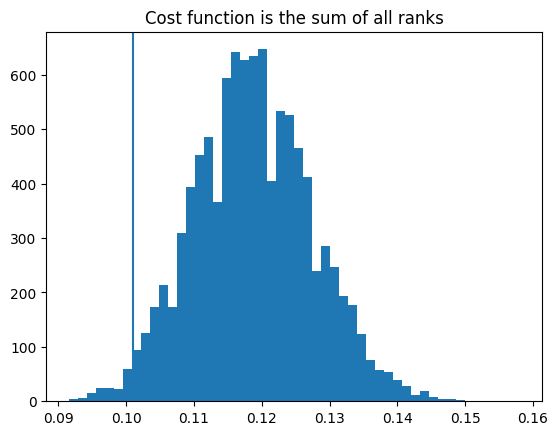

In [18]:
plt.hist(scores, bins=50)
plt.axvline(rank_sum_cost(matching_real['gale_shapley']))
plt.title("Cost function is the sum of all ranks")
plt.show()

In this notebook, I investigate how the implemented algorithms can be used to solve the preference matching problem for the allocation of SD projects at Télécom Paris.

The main challenge is that projects do not provide rankings over students. As a result, classical matching algorithms such as Gale–Shapley and Top Trading Cycles (TTC) cannot be applied directly. To overcome this limitation, one approach is to construct project preferences over students using the scores that students assign to the projects. Once these preferences are defined, the Gale–Shapley algorithm becomes applicable.

A second approach is to use the Serial Dictatorship algorithm. However, this method is heavily biased by the order in which students are considered. To mitigate this issue, we propose running Serial Dictatorship many times while randomly shuffling the student order at each iteration. For each run, we evaluate the resulting allocation according to a chosen criterion (or cost function), such as the percentage of students who receive one of their top three choices.

The experiments show that this procedure produces a distribution of outcomes. By running Serial Dictatorship a sufficiently large number of times, we can identify allocations lying in the region of low cost, which corresponds to more desirable and equitable outcomes.
